# Comparing models trained with LFP loss vs not



In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d

## get list of trained models

In [2]:
# non-lfp models (xlfp)

xlfp_model_dir = '/home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
xlfp_model_list = os.listdir(xlfp_model_dir)
xlfp_model_list = [m for m in xlfp_model_list if m.endswith('.mat')]
xlfp_model_list.sort()
print(xlfp_model_list)
print(len(xlfp_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(xlfp_model_list):
    model_path = os.path.join(xlfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_003716.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004322.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_004840.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_005023.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011004.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_011255.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013220.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013347.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_013838.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_095439.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_100635.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_101851.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_103905.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_105632.mat', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2025_08_27_110756.mat', 'Task_xor

In [3]:
import sys

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld

2025-08-29 14:29:14.266868: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-29 14:29:14.277884: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-29 14:29:14.289424: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-29 14:29:14.292902: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-29 14:29:14.303787: I tensorflow/core/platform/cpu_feature_guar

In [4]:
# lfp models (lfp) — theta

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_theta_model_list = ld.find_files_keywords(lfp_model_dir, ['08_22', '4.0_8.0', '.mat'])
# remove directories 
lfp_theta_model_list = [m.split('/')[-1] for m in lfp_theta_model_list]
lfp_theta_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_theta_model_list = lfp_theta_model_list[:-1]
print(lfp_theta_model_list)
print(len(lfp_theta_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_theta_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

['Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_115633.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_121833.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_122111.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125021.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125231.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125236.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_130054.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_133126.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_134336.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_135118.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_140518.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_143015.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_2

In [10]:
# lfp models (lfp) — alpha

lfp_model_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'
# lfp_model_list = os.listdir(lfp_model_dir)
# lfp_model_list = [m for m in lfp_model_list if m.endswith('.mat') and m.]
lfp_alpha_model_list = ld.find_files_keywords(lfp_model_dir, ['08_21', '9.0_12.0', '.mat'])
# remove directories 
lfp_alpha_model_list = [m.split('/')[-1] for m in lfp_alpha_model_list]
lfp_alpha_model_list.sort()

# remove the last model, which was trained with different parameters
lfp_alpha_model_list = lfp_alpha_model_list[:-1]
print(lfp_alpha_model_list)
print(len(lfp_alpha_model_list))

perfs = []
train_trials = []
for i, model_name in enumerate(lfp_alpha_model_list):
    model_path = os.path.join(lfp_model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perf_mean'][0][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')

['Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_151257.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_153737.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_164712.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_164821.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_172517.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_172805.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_174006.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_174857.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_181822.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_182141.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_183023.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigmoid_2025_08_21_185725.mat', 'Task_xor_N_200_Taus_4.0_25.0_LFP_9.0_12.0_Act_sigm

## study models

In [5]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
import model
from model import generate_input_stim_xor

Instructions for updating:
non-resource variables are not supported in the long term


### extend maintenance

#### 50 to 150

In [6]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 150, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [7]:
u, label = generate_input_stim_xor(settings)
trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]
x, r, o, epsp = model.eval_tf(model_dir=f'{lfp_model_dir}/{lfp_model_list[0]}', settings=settings, u=u)
print(u.shape, label, trial_type)
print(x.shape, r.shape, o.shape, epsp.shape)

(2, 500) same [-1. -1.]
(200, 500) (200, 500) (500,) (500,)


In [30]:
# model eval on 100 random trials

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
eval_perf = np.zeros(n_trials)
eval_os = np.zeros((n_trials, settings['T']))

for i in range(n_trials):
    eval_u, eval_label = generate_input_stim_xor(settings)
    _, _, eval_o, _ = model.eval_tf(model_dir=f'{lfp_model_dir}/{lfp_model_list[0]}', settings=settings, u=eval_u)
    eval_os[i, :] = np.squeeze(eval_o)
    if eval_label == 'same':
        if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
            eval_perf[i] = 1
    else:
        if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
            eval_perf[i] = 1

eval_perf_mean = np.nanmean(eval_perf)
print("Performance: %.2f"%(eval_perf_mean))

Performance: 0.76


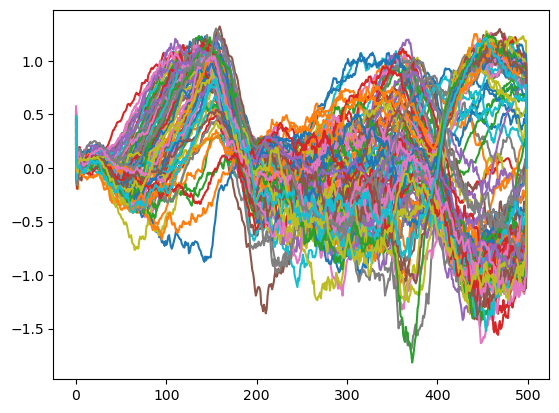

In [31]:
plt.figure()
plt.plot(eval_os.T)
plt.show()

#### check performance

##### delay=150

In [ ]:
# model eval on 100 random trials — LFP theta

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = lfp_model_dir
model_list = lfp_model_list

lfp_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):
    
    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))
    
    lfp_model_perfs[n_model] = eval_perf_mean


Performance: 0.72
Performance: 0.96
Performance: 0.90
Performance: 0.51
Performance: 0.90
Performance: 0.76
Performance: 0.57
Performance: 0.63
Performance: 0.96
Performance: 0.94
Performance: 0.61
Performance: 0.98
Performance: 0.72
Performance: 0.79


In [8]:
# model eval on 100 random trials — LFP alpha

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = lfp_model_dir
model_list = lfp_alpha_model_list

lfp_alpha_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):

    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))

    lfp_alpha_model_perfs[n_model] = eval_perf_mean


Performance: 0.30
Performance: 0.87
Performance: 0.00
Performance: 0.86
Performance: 0.09
Performance: 0.09
Performance: 0.15
Performance: 0.48
Performance: 0.29
Performance: 0.62
Performance: 0.59
Performance: 0.76
Performance: 0.94
Performance: 0.25


In [15]:
# model eval on 100 random trials

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = xlfp_model_dir
model_list = xlfp_model_list

xlfp_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):
    
    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))

    xlfp_model_perfs[n_model] = eval_perf_mean


Performance: 0.89
Performance: 0.91
Performance: 0.79
Performance: 0.88
Performance: 0.92
Performance: 0.73
Performance: 0.94
Performance: 0.59
Performance: 0.60
Performance: 0.73
Performance: 0.70
Performance: 0.84
Performance: 0.88
Performance: 0.99
Performance: 0.35
Performance: 0.95
Performance: 0.92
Performance: 0.97


Mann-Whitney U test statistic: 114.00, p-value: 0.66


/tmp/ipykernel_598571/1948864179.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lfp_model_perfs, xlfp_model_perfs], labels=['LFP', 'X-LFP'])


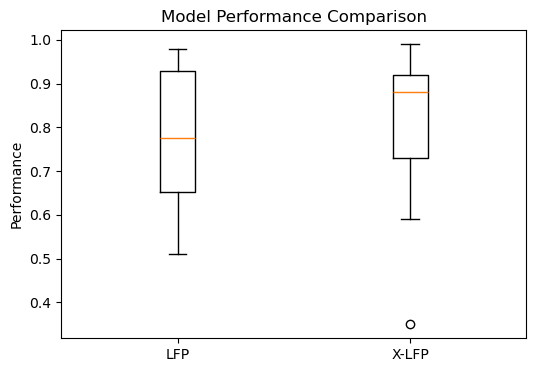

In [17]:
# box plots comparing model perfs from both groups, with stats

plt.figure(figsize=(6,4))
plt.boxplot([lfp_model_perfs, xlfp_model_perfs], labels=['LFP', 'X-LFP'])

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(lfp_model_perfs, xlfp_model_perfs)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))

if p<0.05:
    plt.text(1.2, 0.1, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

In [15]:
lfp_theta_perfs = [0.72, 0.96, 0.90, 0.51, 0.90, 0.76, 0.57, 0.63, 0.96, 0.94, 0.61, 0.98, 0.72, 0.79]
lfp_alpha_perfs = [0.30, 0.87, 0.86, 0.09, 0.09, 0.15, 0.48, 0.29, 0.62, 0.59, 0.76, 0.94, 0.25]
xlfp_perfs = [0.89,  0.91, 0.79, 0.88, 0.92, 0.73, 0.94, 0.59, 0.60, 0.73, 0.70, 0.84, 0.88, 0.99, 0.35, 0.95, 0.92, 0.97]

Mann-Whitney U, theta vs no LFP p-value: 0.66
Mann-Whitney U, alpha vs no LFP p-value: 0.00


/tmp/ipykernel_642598/1668748616.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lfp_theta_perfs, lfp_alpha_perfs, xlfp_perfs], labels=['LFP theta', 'LFP alpha', 'no LFP'])


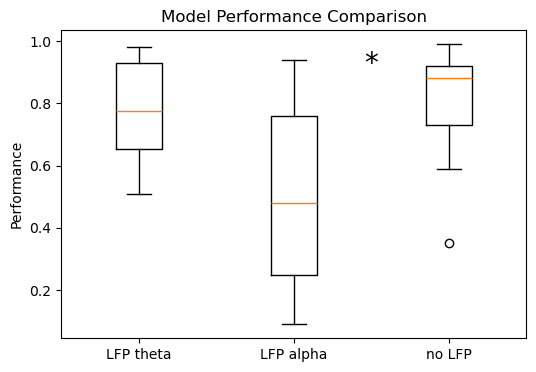

In [19]:
# box plots comparing model perfs from all groups, with stats

plt.figure(figsize=(6,4))
plt.boxplot([lfp_theta_perfs, lfp_alpha_perfs, xlfp_perfs], labels=['LFP theta', 'LFP alpha', 'no LFP'])

from scipy.stats import mannwhitneyu    

_, p_theta = mannwhitneyu(lfp_theta_perfs, xlfp_perfs)
print("Mann-Whitney U, theta vs no LFP p-value: %.2f" % (p_theta))
_, p_alpha = mannwhitneyu(lfp_alpha_perfs, xlfp_perfs)
print("Mann-Whitney U, alpha vs no LFP p-value: %.2f" % (p_alpha))

if p_theta < 0.05:
    plt.text(1.5, 0.9, '*', fontsize=20, ha='center')
if p_alpha < 0.05:
    plt.text(2.5, 0.9, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

##### extend maintenance to 250

In [9]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 250, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# model eval on 100 random trials — LFP theta

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = lfp_model_dir
model_list = lfp_model_list

lfp_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):
    
    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))
    
    lfp_model_perfs[n_model] = eval_perf_mean


Performance: 0.57
Performance: 0.97
Performance: 0.95
Performance: 0.37
Performance: 0.94
Performance: 0.74
Performance: 0.36
Performance: 0.45
Performance: 0.97
Performance: 0.83
Performance: 0.40
Performance: 0.91
Performance: 0.76
Performance: 0.48


In [11]:
# model eval on 100 random trials — LFP alpha

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = lfp_model_dir
model_list = lfp_alpha_model_list

lfp_alpha_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):

    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))

    lfp_alpha_model_perfs[n_model] = eval_perf_mean


Performance: 0.05
Performance: 0.88
Performance: 0.94
Performance: 0.80
Performance: 0.27
Performance: 0.50
Performance: 0.39
Performance: 0.05
Performance: 0.71
Performance: 0.63
Performance: 0.66
Performance: 0.74
Performance: 0.62


In [ ]:
# model eval on 100 random trials — no LFP

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = xlfp_model_dir
model_list = xlfp_model_list

xlfp_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):
    
    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))

    xlfp_model_perfs[n_model] = eval_perf_mean


Performance: 0.69
Performance: 0.71
Performance: 0.36
Performance: 0.81
Performance: 0.83
Performance: 0.46
Performance: 0.74
Performance: 0.17
Performance: 0.40
Performance: 0.48
Performance: 0.68
Performance: 0.84
Performance: 0.91
Performance: 0.97
Performance: 0.10
Performance: 0.95
Performance: 0.86
Performance: 1.00


Mann-Whitney U test statistic: 133.50, p-value: 0.79


/tmp/ipykernel_598571/1948864179.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lfp_model_perfs, xlfp_model_perfs], labels=['LFP', 'X-LFP'])


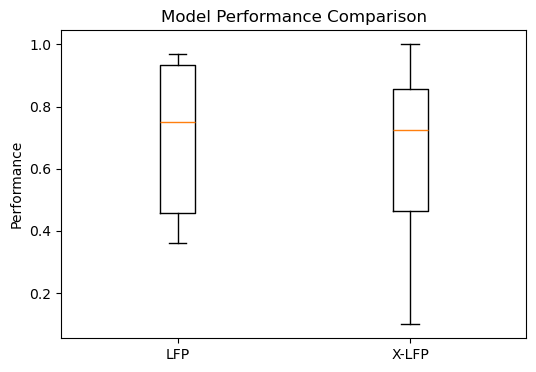

In [23]:
# box plots comparing model perfs from both groups, with stats

plt.figure(figsize=(6,4))
plt.boxplot([lfp_model_perfs, xlfp_model_perfs], labels=['LFP', 'X-LFP'])

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(lfp_model_perfs, xlfp_model_perfs)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))

if p<0.05:
    plt.text(1.2, 0.1, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

In [20]:
lfp_theta_perfs = [0.57, 0.97, 0.95, 0.37, 0.94, 0.74, 0.36, 0.45, 0.97, 0.83, 0.40, 0.91, 0.76, 0.48]
lfp_alpha_perfs = [0.05, 0.88, 0.94, 0.80, 0.27, 0.50, 0.39, 0.05, 0.71, 0.63, 0.66, 0.74, 0.62]
xlfp_perfs = [0.69, 0.71, 0.36, 0.81, 0.83, 0.46, 0.74, 0.17, 0.40, 0.48, 0.68, 0.84, 0.91, 0.97, 0.10, 0.95, 0.86, 1.00]

Mann-Whitney U, theta vs no LFP p-value: 0.79
Mann-Whitney U, alpha vs no LFP p-value: 0.22


/tmp/ipykernel_642598/1668748616.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lfp_theta_perfs, lfp_alpha_perfs, xlfp_perfs], labels=['LFP theta', 'LFP alpha', 'no LFP'])


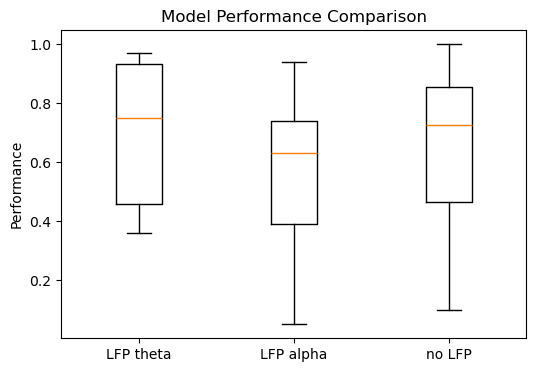

In [21]:
# box plots comparing model perfs from all groups, with stats

plt.figure(figsize=(6,4))
plt.boxplot([lfp_theta_perfs, lfp_alpha_perfs, xlfp_perfs], labels=['LFP theta', 'LFP alpha', 'no LFP'])

from scipy.stats import mannwhitneyu    

_, p_theta = mannwhitneyu(lfp_theta_perfs, xlfp_perfs)
print("Mann-Whitney U, theta vs no LFP p-value: %.2f" % (p_theta))
_, p_alpha = mannwhitneyu(lfp_alpha_perfs, xlfp_perfs)
print("Mann-Whitney U, alpha vs no LFP p-value: %.2f" % (p_alpha))

if p_theta < 0.05:
    plt.text(1.5, 0.9, '*', fontsize=20, ha='center')
if p_alpha < 0.05:
    plt.text(2.5, 0.9, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

##### extend maintenance to 400

In [12]:
settings = {
        'T': 600, # trial duration (in steps)
        'stim_on': 50, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 400, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [ ]:
# model eval on 100 random trials — LFP theta

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = lfp_model_dir
model_list = lfp_model_list

lfp_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):
    
    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))
    
    lfp_model_perfs[n_model] = eval_perf_mean


Performance: 0.50
Performance: 0.94
Performance: 0.79
Performance: 0.48
Performance: 0.91
Performance: 0.61
Performance: 0.34
Performance: 0.34
Performance: 0.98
Performance: 0.59
Performance: 0.49
Performance: 0.87
Performance: 0.44
Performance: 0.51


In [13]:
# model eval on 100 random trials — LFP alpha

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = lfp_model_dir
model_list = lfp_alpha_model_list

lfp_alpha_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):

    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))

    lfp_alpha_model_perfs[n_model] = eval_perf_mean


Performance: 0.33
Performance: 0.58
Performance: 0.35
Performance: 0.20
Performance: 0.51
Performance: 0.37
Performance: 0.20
Performance: 0.23
Performance: 0.45
Performance: 0.07
Performance: 0.36
Performance: 0.72
Performance: 0.39


In [ ]:
# model eval on 100 random trials — no LFP

n_trials = 100
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7

model_dir = xlfp_model_dir
model_list = xlfp_model_list

xlfp_model_perfs = np.zeros(len(model_list))
for n_model, model_name in enumerate(model_list):
    
    eval_perf = np.zeros(n_trials)
    eval_os = np.zeros((n_trials, settings['T']))

    for i in range(n_trials):
        eval_u, eval_label = generate_input_stim_xor(settings)
        _, _, eval_o, _ = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=eval_u)
        eval_os[i, :] = np.squeeze(eval_o)
        if eval_label == 'same':
            if np.max(eval_o[resp_onset:]) > eval_amp_threshold:
                eval_perf[i] = 1
        else:
            if np.min(eval_o[resp_onset:]) < -eval_amp_threshold:
                eval_perf[i] = 1

    eval_perf_mean = np.nanmean(eval_perf)
    print("Performance: %.2f"%(eval_perf_mean))

    xlfp_model_perfs[n_model] = eval_perf_mean


Performance: 0.51
Performance: 0.58
Performance: 0.19
Performance: 0.70
Performance: 0.59
Performance: 0.34
Performance: 0.63
Performance: 0.21
Performance: 0.35
Performance: 0.43
Performance: 0.69
Performance: 0.67
Performance: 0.90
Performance: 0.98
Performance: 0.74
Performance: 0.90
Performance: 0.76
Performance: 0.98


Mann-Whitney U test statistic: 123.00, p-value: 0.92


/tmp/ipykernel_598571/1948864179.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lfp_model_perfs, xlfp_model_perfs], labels=['LFP', 'X-LFP'])


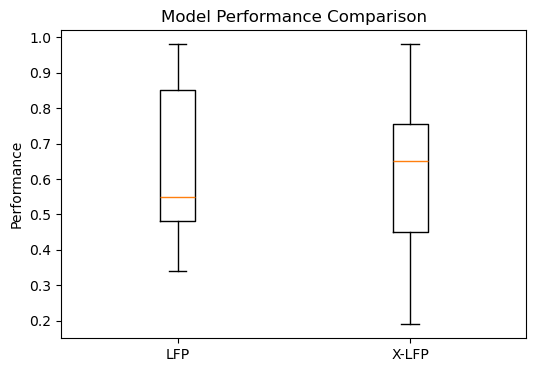

In [27]:
# box plots comparing model perfs from both groups, with stats

plt.figure(figsize=(6,4))
plt.boxplot([lfp_model_perfs, xlfp_model_perfs], labels=['LFP', 'X-LFP'])

from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(lfp_model_perfs, xlfp_model_perfs)
print("Mann-Whitney U test statistic: %.2f, p-value: %.2f" % (stat, p))

if p<0.05:
    plt.text(1.2, 0.1, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

In [23]:
lfp_theta_perfs = [0.50, 0.94, 0.79, 0.48, 0.91, 0.61, 0.34, 0.34, 0.98, 0.59, 0.49, 0.87, 0.44, 0.51]
lfp_alpha_perfs = [0.33, 0.58, 0.35, 0.20, 0.51, 0.37, 0.20, 0.23, 0.45, 0.07, 0.36, 0.72, 0.39]
xlfp_perfs = [0.51, 0.58, 0.19, 0.70, 0.59, 0.34, 0.63, 0.21, 0.35, 0.43, 0.69, 0.67, 0.90, 0.98, 0.74, 0.90, 0.76, 0.98]

Mann-Whitney U, theta vs no LFP p-value: 0.92
Mann-Whitney U, alpha vs no LFP p-value: 0.01


/tmp/ipykernel_642598/1668748616.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lfp_theta_perfs, lfp_alpha_perfs, xlfp_perfs], labels=['LFP theta', 'LFP alpha', 'no LFP'])


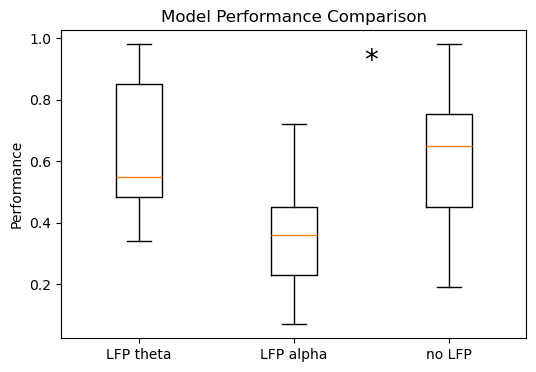

In [24]:
# box plots comparing model perfs from all groups, with stats

plt.figure(figsize=(6,4))
plt.boxplot([lfp_theta_perfs, lfp_alpha_perfs, xlfp_perfs], labels=['LFP theta', 'LFP alpha', 'no LFP'])

from scipy.stats import mannwhitneyu    

_, p_theta = mannwhitneyu(lfp_theta_perfs, xlfp_perfs)
print("Mann-Whitney U, theta vs no LFP p-value: %.2f" % (p_theta))
_, p_alpha = mannwhitneyu(lfp_alpha_perfs, xlfp_perfs)
print("Mann-Whitney U, alpha vs no LFP p-value: %.2f" % (p_alpha))

if p_theta < 0.05:
    plt.text(1.5, 0.9, '*', fontsize=20, ha='center')
if p_alpha < 0.05:
    plt.text(2.5, 0.9, '*', fontsize=20, ha='center')

plt.ylabel('Performance')
plt.title('Model Performance Comparison')
# plt.grid()
plt.show()

#### generate data

In [ ]:
# model eval on 100 trials -- DO NOT RUN

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]

neural_dict = {
    'r': [],
    'epsp': []
}

bhv_dict = {
    'perf': [],
    'trial_type': []
}

for n in range(n_trials):
    for stim1 in stim1s:
        for stim2 in stim2s:
            u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
            trial_type = [stim1, stim2]
            # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

            _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)

            neural_dict['r'].append(r)
            neural_dict['epsp'].append(epsp)
            
            if label == 'same':
                if np.max(o[resp_onset:]) > eval_amp_threshold:
                    bhv_dict['perf'].append(1)
                else:
                    bhv_dict['perf'].append(0)
            else:
                if np.min(o[resp_onset:]) < -eval_amp_threshold:
                    bhv_dict['perf'].append(1)
                else:
                    bhv_dict['perf'].append(0)

            bhv_dict['trial_type'].append(trial_type)

neural_dict['r'] = np.array(neural_dict['r'])
neural_dict['epsp'] = np.array(neural_dict['epsp'])
bhv_dict['perf'] = np.array(bhv_dict['perf'])

In [6]:
import pickle as pk

In [9]:
def generate_xor_type(settings, stim1=1, stim2=-1):
     
     u = np.zeros((2, settings['T']))

     u[0, settings['stim_on']:settings['stim_on']+settings['stim_dur']] = stim1
     u[1, settings['stim_on']+settings['stim_dur']+settings['delay']:
          settings['stim_on']+2*settings['stim_dur']+settings['delay']] = stim2

     if stim1 == stim2:
          label = 'same'
     else: 
          label = 'diff'
     
     return u, label

In [7]:
settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 150, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 150, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'lfp_power_target': [4, 8], # theta
        'fs': 200,
        'task': 'xor', # task name
        }

In [10]:
# for LFP models

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = lfp_model_dir
model_list = lfp_theta_model_list

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)
    
    # check if saved neural_dict and bhv_dict already
    if os.path.exists(os.path.join(output_dir, 'neural_dict.pkl')) and os.path.exists(os.path.join(output_dir, 'bhv_dict.pkl')):
        print(f'skipping {model_name}, already saved')
        continue

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, 'neural_dict.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, 'bhv_dict.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

skipping Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_115633.mat, already saved
skipping Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_121833.mat, already saved
skipping Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_122111.mat, already saved
skipping Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125021.mat, already saved
skipping Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125231.mat, already saved
skipping Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_125236.mat, already saved
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_130054/
✔ Saved model outputs to /home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_133126/
✔ Saved model outputs to /home/nuttidalab/Documents/re

In [ ]:
# for non-LFP models

n_trials = 25
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
eval_amp_threshold = 0.7
stim1s = [-1,1]
stim2s = [-1,1]
model_dir = xlfp_model_dir
model_list = xlfp_model_list

for n_model, model_name in enumerate(model_list):
    
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)

    neural_dict = {
        'r': [],
        'epsp': []
    }

    bhv_dict = {
        'perf': [],
        'trial_type': []
    }

    for stim1 in stim1s:
        for stim2 in stim2s:
            for n in range(n_trials):
                u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
                trial_type = [stim1, stim2]
                # trial_type = np.unique(u, axis=1)[np.where(np.unique(u, axis=1) != 0)]

                _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)

                neural_dict['r'].append(r)
                neural_dict['epsp'].append(epsp)
                
                if label == 'same':
                    if np.max(o[resp_onset:]) > eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)
                else:
                    if np.min(o[resp_onset:]) < -eval_amp_threshold:
                        bhv_dict['perf'].append(1)
                    else:
                        bhv_dict['perf'].append(0)

                bhv_dict['trial_type'].append(trial_type)

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])
    bhv_dict['perf'] = np.array(bhv_dict['perf'])
    
    # save
    with open(os.path.join(output_dir, 'neural_dict.pkl'), 'wb') as f:
        pk.dump(neural_dict, f)

    with open(os.path.join(output_dir, 'bhv_dict.pkl'), 'wb') as f:
        pk.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

In [ ]:
import os
import numpy as np
import pickle
from concurrent.futures import ProcessPoolExecutor
from itertools import product

def generate_data(trial_index, stim1, stim2, settings, model_dir, model_name, eval_amp_threshold, resp_onset):
    u, label = generate_xor_type(settings, stim1=stim1, stim2=stim2)
    trial_type = [stim1, stim2]

    _, r, o, epsp = model.eval_tf(model_dir=f'{model_dir}/{model_name}', settings=settings, u=u)

    if label == 'same':
        perf = int(np.max(o[resp_onset:]) > eval_amp_threshold)
    else:
        perf = int(np.min(o[resp_onset:]) < -eval_amp_threshold)

    # Return minimal, serializable result
    return {
        'trial_index': trial_index,
        'stim1': stim1,
        'stim2': stim2,
        'r': r,
        'epsp': epsp,
        'perf': perf,
        'trial_type': trial_type
    }


In [ ]:
## LFP MODELS

# ---- Settings ----
n_trials = 25
stim1s = [-1, 1]
stim2s = [-1, 1]
eval_amp_threshold = 0.7
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
model_dir = lfp_model_dir
model_list = lfp_model_list

# ---- Loop over models ----
for model_name in model_list:
    print(f"\nRunning model: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)

    # Generate all (trial, stim1, stim2) combinations
    trial_stim_combos = [
        (trial_index, stim1, stim2)
        for trial_index in range(n_trials)
        for stim1, stim2 in product(stim1s, stim2s)
    ]

    # Run in parallel
    with ProcessPoolExecutor() as executor:
        futures = [
            executor.submit(
                generate_data,
                trial_index, stim1, stim2,
                settings, model_dir, model_name,
                eval_amp_threshold, resp_onset
            )
            for (trial_index, stim1, stim2) in trial_stim_combos
        ]

        results = [f.result() for f in futures]

    # Aggregate results
    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': []}

    for res in results:
        neural_dict['r'].append(res['r'])
        neural_dict['epsp'].append(res['epsp'])
        bhv_dict['perf'].append(res['perf'])
        bhv_dict['trial_type'].append(res['trial_type'])

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])

    # Save
    with open(os.path.join(output_dir, 'neural_dict.pkl'), 'wb') as f:
        pickle.dump(neural_dict, f)

    with open(os.path.join(output_dir, 'bhv_dict.pkl'), 'wb') as f:
        pickle.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

In [ ]:
## non-LFP MODELS

# ---- Settings ----
n_trials = 25
stim1s = [-1, 1]
stim2s = [-1, 1]
eval_amp_threshold = 0.7
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
model_dir = xlfp_model_dir
model_list = xlfp_model_list

# ---- Loop over models ----
for model_name in model_list:
    print(f"\nRunning model: {model_name}")
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    os.makedirs(output_dir, exist_ok=True)

    # Generate all (trial, stim1, stim2) combinations
    trial_stim_combos = [
        (trial_index, stim1, stim2)
        for trial_index in range(n_trials)
        for stim1, stim2 in product(stim1s, stim2s)
    ]

    # Run in parallel
    with ProcessPoolExecutor() as executor:
        futures = [
            executor.submit(
                generate_data,
                trial_index, stim1, stim2,
                settings, model_dir, model_name,
                eval_amp_threshold, resp_onset
            )
            for (trial_index, stim1, stim2) in trial_stim_combos
        ]

        results = [f.result() for f in futures]

    # Aggregate results
    neural_dict = {'r': [], 'epsp': []}
    bhv_dict = {'perf': [], 'trial_type': []}

    for res in results:
        neural_dict['r'].append(res['r'])
        neural_dict['epsp'].append(res['epsp'])
        bhv_dict['perf'].append(res['perf'])
        bhv_dict['trial_type'].append(res['trial_type'])

    neural_dict['r'] = np.array(neural_dict['r'])
    neural_dict['epsp'] = np.array(neural_dict['epsp'])

    # Save
    with open(os.path.join(output_dir, 'neural_dict.pkl'), 'wb') as f:
        pickle.dump(neural_dict, f)

    with open(os.path.join(output_dir, 'bhv_dict.pkl'), 'wb') as f:
        pickle.dump(bhv_dict, f)

    print(f"✔ Saved model outputs to {output_dir}")

In [ ]:
## old

# ---- Main Execution for non-LFP models----

n_trials = 25
stim1s = [-1, 1]
stim2s = [-1, 1]
eval_amp_threshold = 0.7
resp_onset = settings['stim_on'] + 2*settings['stim_dur'] + settings['delay']
model_dir = xlfp_model_dir
model_list = xlfp_model_list

for model_name in model_list:
    print(f"\nRunning model: {model_name}")

    # Accumulators for all trials
    all_neural = {'r': [], 'epsp': []}
    all_bhv = {'perf': [], 'trial_type': []}

    with ProcessPoolExecutor() as executor:
        futures = [
            executor.submit(
                generate_data,
                n,
                settings,
                model_dir,
                model_name,
                stim1s,
                stim2s,
                eval_amp_threshold,
                resp_onset
            )
            for n in range(n_trials)
        ]

        for future in futures:
            neural_data, bhv_data = future.result()
            all_neural['r'].extend(neural_data['r'])
            all_neural['epsp'].extend(neural_data['epsp'])
            all_bhv['perf'].extend(bhv_data['perf'])
            all_bhv['trial_type'].extend(bhv_data['trial_type'])

    # Convert to numpy arrays
    all_neural['r'] = np.array(all_neural['r'])
    all_neural['epsp'] = np.array(all_neural['epsp'])

    # Create model output folder
    output_dir = os.path.join(model_dir, model_name[:-4])
    os.makedirs(output_dir, exist_ok=True)

    # Save pickled dicts
    with open(os.path.join(output_dir, 'neural_dict.pkl'), 'wb') as f:
        pk.dump(all_neural, f)

    with open(os.path.join(output_dir, 'bhv_dict.pkl'), 'wb') as f:
        pk.dump(all_bhv, f)

    print(f"Saved neural and behavioral data to: {output_dir}")

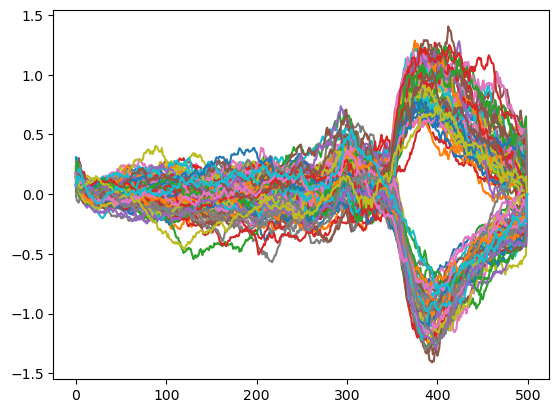

In [15]:
plt.figure()
plt.plot(eval_os.T)
plt.show()

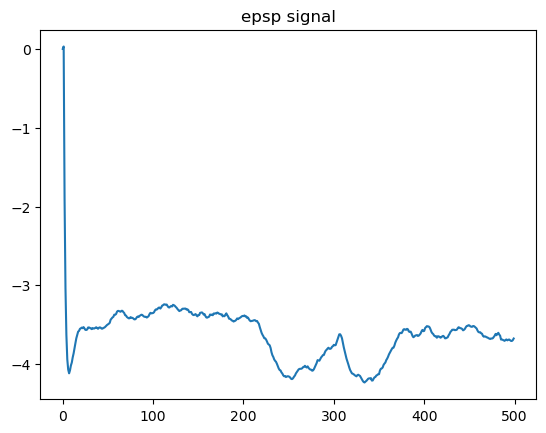

In [16]:
# check out the epsp signal

plt.figure()
plt.plot(epsp.T)
plt.title('epsp signal')
plt.show()

In [22]:
# spect calculation code in numpy

def compute_lfp_power_np(epsp, settings):
    """
    Compute band-limited z-scored LFP power using Morlet wavelets (NumPy version).

    Parameters
    ----------
    epsp : list or np.ndarray
        Length-T list or array of scalar values (e.g., EPSP signal).
    settings : dict
        Dictionary containing:
            - 'T': int, length of the signal
            - 'fs': float, sampling frequency in Hz
            - 'lfp_power_target': list or tuple of [low_freq, high_freq]
            - 'stim_on': int, time index of stimulus onset

    Returns
    -------
    lfp_power_z : np.ndarray
        Z-scored LFP power in the target frequency band. Shape [T]
    """
    # --- settings ---
    T = settings['T']
    fs = settings['fs']
    dt = 1.0 / fs
    fmin, fmax = 4.0, 100.0
    num_freqs = 40
    band_lo, band_hi = settings['lfp_power_target']
    stim_on = settings['stim_on']

    # --- epsp input processing ---
    epsp_vec = np.squeeze(np.stack(epsp, axis=0))  # [T]
    epsp_sig = np.reshape(epsp_vec, [1, T, 1])      # [1, T, 1]

    # --- frequencies & scales ---
    freqs = np.exp(np.linspace(np.log(fmin), np.log(fmax), num_freqs))
    fc = 0.8125  # Morlet central frequency
    scales = fc / (freqs * dt)

    # --- build Morlet kernels ---
    K = 6.0
    f_low = fmin
    sigma_t_low = K / (2.0 * np.pi * f_low)
    half_width_sec = 4.0 * sigma_t_low
    kernel_len = int(round(2.0 * half_width_sec * fs) + 1)
    kernel_len = max(kernel_len, 31)

    t_idx = np.arange(kernel_len, dtype=np.float32) - (kernel_len - 1) / 2.0
    t_sec = t_idx / fs

    two_pi = 2.0 * np.pi
    sigma_t = K / (two_pi * freqs)  # [F]

    env = np.exp(-0.5 * (np.expand_dims(t_sec, 1) / np.expand_dims(sigma_t, 0))**2)
    phase = two_pi * np.expand_dims(t_sec, 1) * np.expand_dims(freqs, 0)
    cos_part = env * np.cos(phase)
    sin_part = env * np.sin(phase)

    # L2 normalize
    eps_norm = 1e-8
    norm = np.sqrt(np.sum(cos_part**2 + sin_part**2, axis=0, keepdims=True) + eps_norm)
    cos_part /= norm
    sin_part /= norm

    # Filters: [L, 1, F]
    cos_filt = np.expand_dims(cos_part, axis=1)
    sin_filt = np.expand_dims(sin_part, axis=1)

    # --- convolution with SAME padding ---
    def conv1d_same(x, filt):
        pad_len = filt.shape[0] // 2
        x_padded = np.pad(x, ((0, 0), (pad_len, pad_len), (0, 0)), mode='constant')
        output = np.zeros((x.shape[0], x.shape[1], filt.shape[2]))
        for f in range(filt.shape[2]):
            kernel = filt[:, 0, f][::-1]  # reverse for conv
            for b in range(x.shape[0]):
                output[b,:,f] = np.convolve(x_padded[b,:,0], kernel, mode='valid')
        return output

    real_coeff = conv1d_same(epsp_sig, cos_filt)  # [1, T, F]
    imag_coeff = conv1d_same(epsp_sig, sin_filt)  # [1, T, F]
    power = real_coeff**2 + imag_coeff**2        # [1, T, F]
    power = np.squeeze(power, axis=0)            # [T, F]

    # --- band selection ---
    band_mask = np.logical_and(freqs >= band_lo, freqs <= band_hi)
    band_mask_f = band_mask.astype(np.float32)
    denom = max(np.sum(band_mask_f), 1.0)
    band_power = np.dot(power, band_mask_f / denom)  # [T]

    # --- baseline z-scoring ---
    start = 10
    stop = int(stim_on)
    base_slice = band_power[start:stop]
    base_mean = np.mean(base_slice)
    base_std = np.std(base_slice) + 1e-8
    lfp_power_z = (band_power - base_mean) / base_std  # [T]

    return power, freqs, lfp_power_z


(500, 40)
(40,)
(500,)


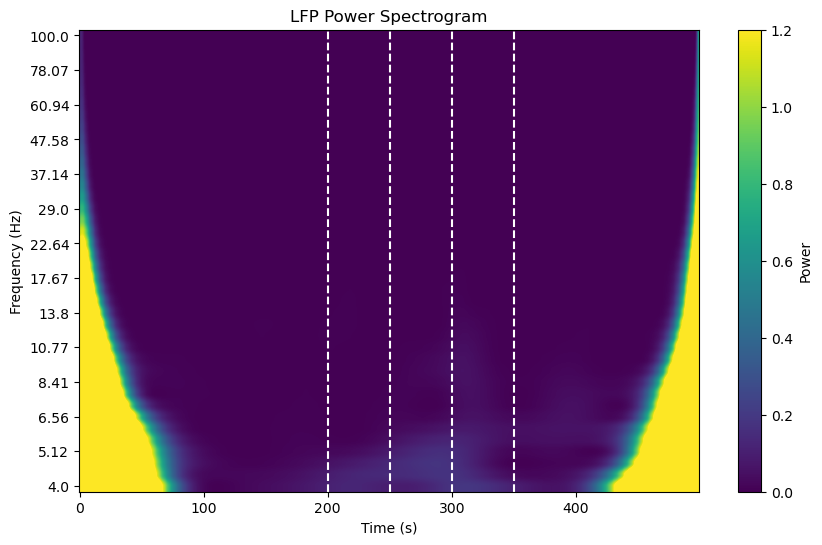

In [24]:
# plot spect

power, freqs, lfp_power_z = compute_lfp_power_np(epsp, settings)
print(power.shape)
print(freqs.shape)
print(lfp_power_z.shape)

time_cutoff = 25

plt.figure(figsize=(10, 6))
# plt.imshow(power[time_cutoff:,:].T, aspect='auto', extent=[time_cutoff, T, fmin, fmax], origin='lower',
#            vmin=0, vmax=1.2)
plt.imshow(power.T, aspect='auto', origin='lower',
           vmin=0, vmax=1.2)
# plt.axhline(y=band_lo, color='r', linestyle='--', label='Band low')
# plt.axhline(y=band_hi, color='r', linestyle='--', label='Band high')
plt.yticks()
plt.yticks(np.arange(0, 40, 3), np.round(freqs[::3], 2))
plt.axvline(x=settings['stim_on'], color='w', linestyle='--', label='Stim on')
plt.axvline(x=settings['stim_on'] + settings['stim_dur'], color='w', linestyle='--', label='Stim off')
plt.axvline(x=settings['stim_on'] + settings['stim_dur'] + settings['delay'], color='w', linestyle='--', label='2nd Stim on')
plt.axvline(x=settings['stim_on'] + 2*settings['stim_dur'] + settings['delay'], color='w', linestyle='--', label='2nd Stim off')
plt.colorbar(label='Power')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('LFP Power Spectrogram')
plt.show()

### Trajectory plots

In [25]:

from sklearn.decomposition import PCA


In [31]:
model_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'x0', 'r0', 'w0', 'taus_gaus0', 'w_in0', 'u', 'o', 'w', 'x', 'target', 'w_out', 'r', 'm', 'som_m', 'N', 'exc', 'inh', 'w_in', 'b_out', 'som_N', 'losses', 'taus', 'eval_perf_mean', 'eval_loss_mean', 'eval_os', 'eval_labels', 'taus_gaus', 'tr', 'activation'])

In [37]:
r = model_data['r']
r = np.squeeze(r)
r.shape

exc = model_data['exc']
exc_ind = np.where(exc == 1)[0]
inh = model_data['inh']
inh_ind = np.where(inh == 1)[0]

X (r): time x neurons  

U: time x n_components  

S: n_components  

Vt: n_components x neurons  

In [28]:
# X = USVt

pca = PCA(n_components=100).fit(r)
r_U = pca.transform(r)
r_S = pca.singular_values_
r_Vt = pca.components_

print(r_U.shape)
print(r_S.shape)
print(r_Vt.shape)

(500, 100)
(100,)
(100, 200)


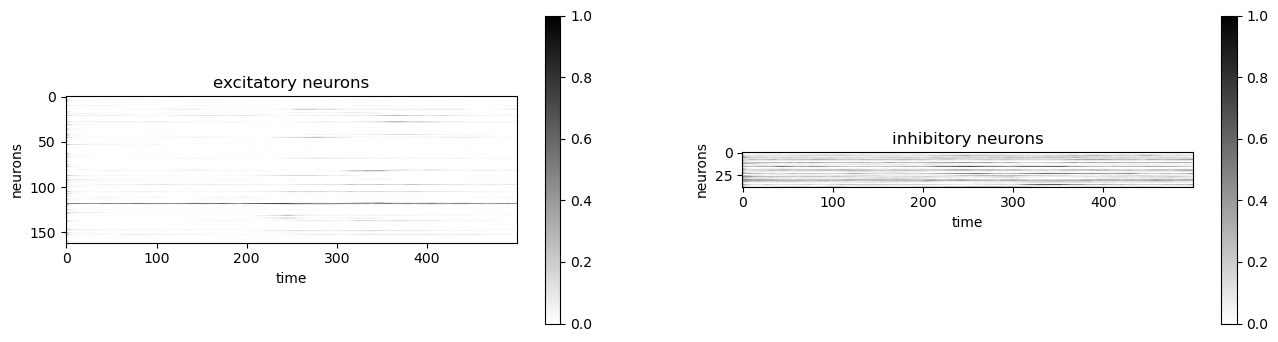

162 excitatory neurons
38 inhibitory neurons


In [38]:
fig,axs = plt.subplots(1,2,figsize=(16,4))
im1 = axs[0].imshow(r[:,exc_ind].T,cmap='binary',vmin=0, vmax=1)
axs[0].set_xlabel('time')
axs[0].set_ylabel('neurons')
axs[0].set_title('excitatory neurons')
fig.colorbar(im1)

im2 = axs[1].imshow(r[:,inh_ind].T,cmap='binary',vmin=0, vmax=1)
axs[1].set_xlabel('time')
axs[1].set_ylabel('neurons')
axs[1].set_title('inhibitory neurons')
fig.colorbar(im2)

plt.show()

print(f'{len(exc_ind)} excitatory neurons')
print(f'{len(inh_ind)} inhibitory neurons')

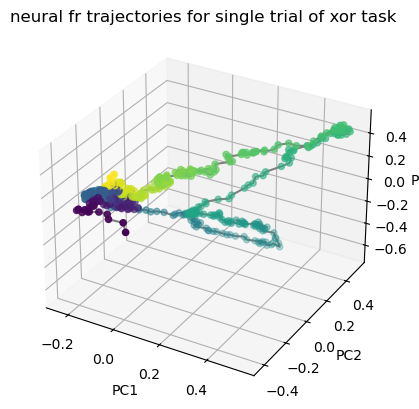

In [41]:
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(r_U[5:,0], r_U[5:,1], r_U[5:,2], c=range(r_U.shape[0]-5))
ax.plot3D(r_U[5:,0], r_U[5:,1], r_U[5:,2], 'gray')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('neural fr trajectories for single trial of xor task')
plt.show()

### some connectivity stuff

In [44]:
all_models_dir = '/home/nuttidalab/Documents/renee/nonlfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/'

In [49]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import connectivity_utils as cu

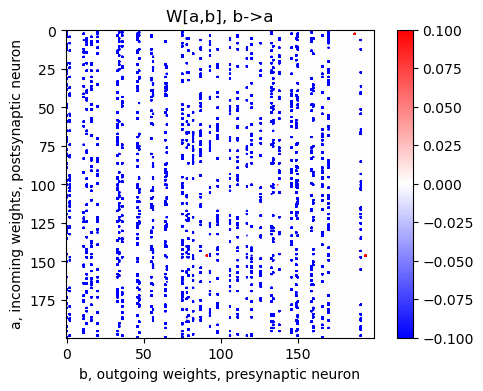

In [52]:
w = model_data['w']
m = model_data['m']
final_w = np.matmul(w, m)
cu.plot_connectivity_matrix(final_w)

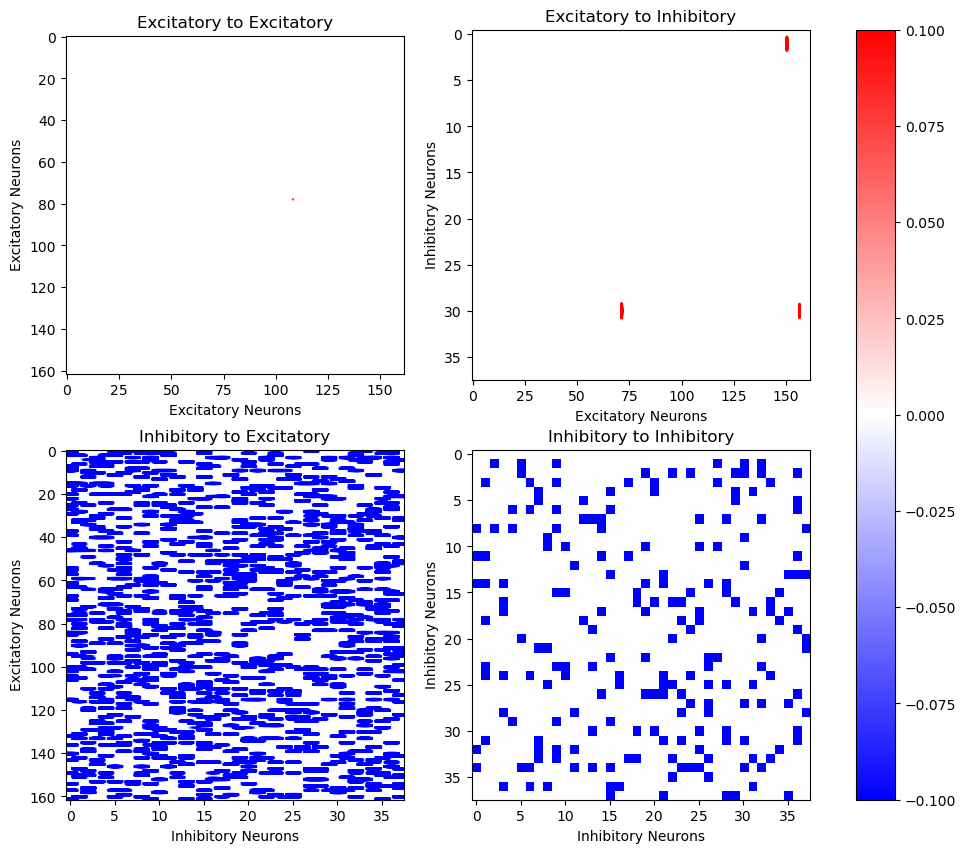

In [53]:
cu.plot_connectivity_matrix_by_type(final_w, exc_ind, inh_ind)

In [54]:
def get_num_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ii != 0), np.sum(ee != 0), np.sum(ei != 0), np.sum(ie != 0), 

def get_proportion_connections(W, exc_ind, inh_ind):
    ee_mask = np.ix_(exc_ind, exc_ind)
    ie_mask = np.ix_(exc_ind, inh_ind)
    ei_mask = np.ix_(inh_ind, exc_ind)
    ii_mask = np.ix_(inh_ind, inh_ind)

    ee = W[ee_mask]
    ie = W[ie_mask]
    ei = W[ei_mask]
    ii = W[ii_mask]

    return np.sum(ee != 0) / ee.size, np.sum(ii != 0) / ii.size, np.sum(ei != 0) / ei.size, np.sum(ie != 0) / ie.size

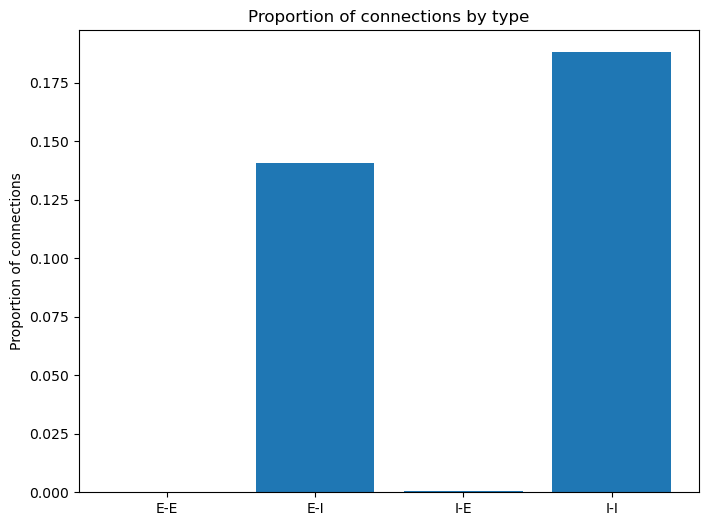

In [55]:
connect_props = get_proportion_connections(final_w, exc_ind, inh_ind)

plt.figure(figsize=(8, 6))
plt.bar(['E-E', 'E-I', 'I-E', 'I-I'], connect_props)
plt.ylabel('Proportion of connections')
plt.title('Proportion of connections by type')
plt.show()

In [ ]:
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate')
from model import FR_RNN_dale


In [58]:
# plot comparing trained and untrained

trained_num = []
untrained_num = []
trained_prop = []
untrained_prop = []

for model_num in range(len(model_list)):
    
    model_path = os.path.join(model_dir, model_name)
    model_data = scipy.io.loadmat(model_path)
    
    # trained
    w = model_data['w']
    m = model_data['m']
    W = np.matmul(w, m)
    
    exc = model_data['exc']
    exc_ind = np.where(exc == 1)[0]
    inh = model_data['inh']
    inh_ind = np.where(inh == 1)[0]
    
    
    trained_num.append(get_num_connections(W, exc_ind, inh_ind))
    trained_prop.append(get_proportion_connections(W, exc_ind, inh_ind))

    # untrained
    N = 200
    net = FR_RNN_dale(N, .2, .2, np.float32(np.random.randn(N, 2)), 0, 'gaus', 1.5, True, np.float32(np.random.randn(1, N)/100))
    W_init = net.W @ net.mask
    exc_ind_init = np.where(net.exc == 1)[0]
    inh_ind_init = np.where(net.exc == 0)[0]

    untrained_num.append(get_num_connections(W_init, exc_ind_init, inh_ind_init))
    untrained_prop.append(get_proportion_connections(W_init, exc_ind_init, inh_ind_init))
# convert to numpy arrays
trained_num = np.array(trained_num)
untrained_num = np.array(untrained_num)
trained_prop = np.array(trained_prop)
untrained_prop = np.array(untrained_prop)

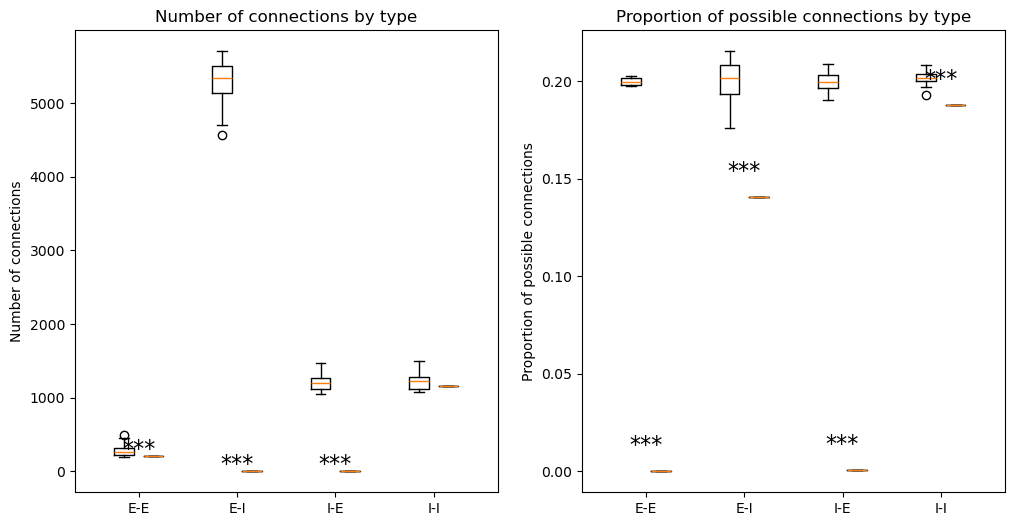

In [59]:
# plot trained vs untrained number of connections

connection_types = ['E-E', 'E-I', 'I-E', 'I-I']
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].boxplot(untrained_num, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[0].boxplot(trained_num, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[0].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[0].set_ylabel('Number of connections')
axs[0].set_title('Number of connections by type')
# axs[0].legend()

axs[1].boxplot(untrained_prop, positions=np.arange(len(connection_types)), widths=0.2, label='trained')
axs[1].boxplot(trained_prop, positions=np.arange(len(connection_types)) + 0.3, widths=0.2, label='untrained')
axs[1].set_xticks(np.arange(len(connection_types)) + 0.15, connection_types)
axs[1].set_ylabel('Proportion of possible connections')
axs[1].set_title('Proportion of possible connections by type')
# axs[1].legend() 

# plot mann whitney U test results for num and proportion of connections
from scipy.stats import mannwhitneyu
p_values_num = []
p_values_prop = []
# for number of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_num[:, i], untrained_num[:, i])
    p_values_num.append(p)
p_values_num = np.array(p_values_num)

# for proportion of connections
for i in range(len(connection_types)):
    stat, p = mannwhitneyu(trained_prop[:, i], untrained_prop[:, i])
    p_values_prop.append(p)
p_values_prop = np.array(p_values_prop)

# plot p-values as stars on top of the boxplots
for i, p in enumerate(p_values_num):
    if p < 0.001:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[0].text(i+.15, np.max(trained_num[:, i]) + 0.1, '*', fontsize=16, ha='center')
    
for i, p in enumerate(p_values_prop):
    if p < 0.001:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '***', fontsize=16, ha='center')
    elif p < 0.01:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '**', fontsize=16, ha='center')
    elif p < 0.05:
        axs[1].text(i+.15, np.max(trained_prop[:, i]) + 0.01, '*', fontsize=16, ha='center')

# plt.tight_layout()

plt.show()

### neural outputs from spiking model

In [14]:
import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld
import single_neuron_utils as sn

In [20]:
all_models_dir = '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0'

model_name = model_fname[:-4]
model_dir = os.path.join(all_models_dir, model_name)
delay=50

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
data_files

['/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/neuraldata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/timingdata_raw_delay50.mat',
 '/home/nuttidalab/Documents/renee/lfp_models/models/xor/P_rec_0.2_Taus_4.0_25.0/Task_xor_N_200_Taus_4.0_25.0_LFP_4.0_8.0_Act_sigmoid_2025_08_22_180642/bhvdata_raw_delay50.mat']

In [21]:
# neural data
lfp_data, spk_times_df, rates_data = ld.load_neural_data(model_name, condn_phrase=f'delay{delay}',
                                                  load_LFP=True, load_spikes=True, load_rates=True,
                                                  all_models_dir = all_models_dir)
# behavioral data
trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)

# timing data
_, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase='delay', condn_num=delay,
                                             all_models_dir=all_models_dir)
times_ms, _,_ = ld.get_times_dict('ds', 'delay', 50, model_name,
                                  all_models_dir=all_models_dir)

In [22]:
print(f'Average performance for delay {delay}: {trial_perfs.mean()}')

Average performance for delay 50: 0.511


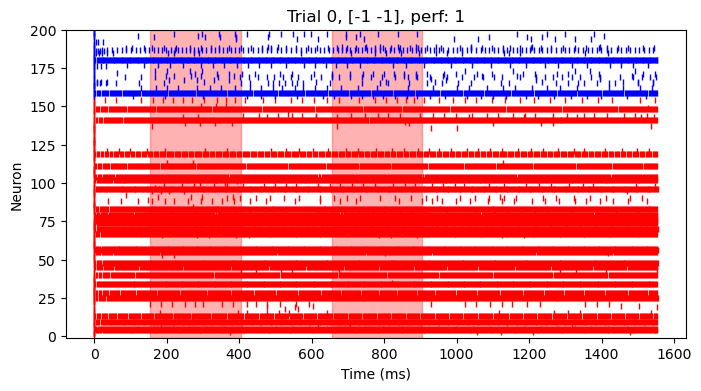

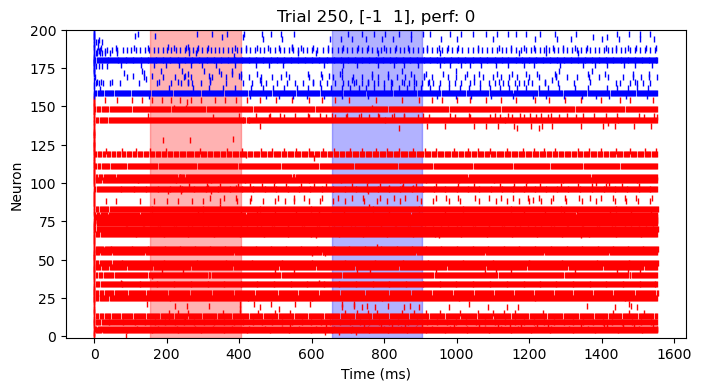

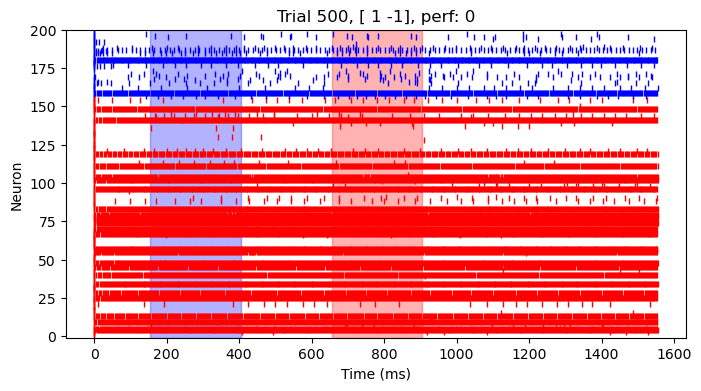

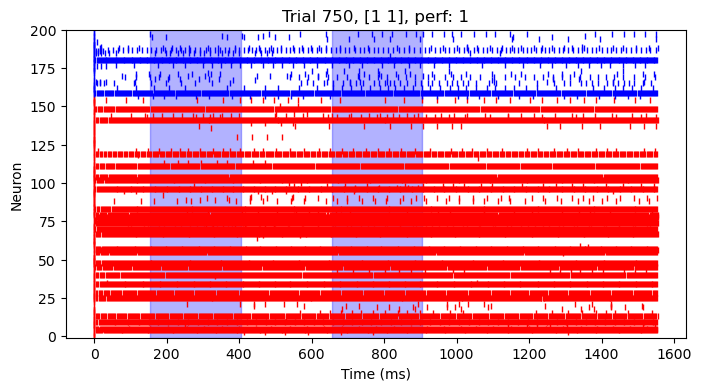

In [23]:
for trial_id in [0, 250, 500, 750]:
    trial_df = spk_times_df[spk_times_df['trial_id'] == trial_id]
    sn.plot_trial_raster(trial_df, 'delay', 50, all_models_dir=all_models_dir,)